In [3]:
!python3 -m pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
df = pd.read_csv('/Users/arhamadeem/Desktop/minecraft internship/housing.csv')

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/arhamadeem/Desktop/minecraft internship/housing.csv'

In [6]:
df = pd.read_csv('housing.csv')

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [8]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [9]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [10]:
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

In [11]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


In [12]:
X = df.drop('median_house_value', axis=1)

y = df['median_house_value']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [15]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [16]:
print("R2 Score:", r2_score(y_test, lr_pred))

print("MAE:", mean_absolute_error(y_test, lr_pred))

print("MSE:", mean_squared_error(y_test, lr_pred))

R2 Score: 0.6254240620553605
MAE: 50670.73824097191
MSE: 4908476721.156617


In [17]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train_scaled, y_train)

dt_pred = dt.predict(X_test_scaled)

In [18]:
print("R2 Score:", r2_score(y_test, dt_pred))

print("MAE:", mean_absolute_error(y_test, dt_pred))

print("MSE:", mean_squared_error(y_test, dt_pred))

R2 Score: 0.6294725691776935
MAE: 44120.67999031008
MSE: 4855424720.340843


In [19]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train_scaled, y_train)

rf_pred = rf.predict(X_test_scaled)

In [20]:
print("R2 Score:", r2_score(y_test, rf_pred))

print("MAE:", mean_absolute_error(y_test, rf_pred))

print("MSE:", mean_squared_error(y_test, rf_pred))

R2 Score: 0.8167090228826115
MAE: 31631.0186749031
MSE: 2401861420.4517317


In [21]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    
    'R2 Score': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ],
    
    'MAE': [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred)
    ]
})

results

,Model,R2 Score,MAE
0,Linear Regression,0.625424,50670.738241
1,Decision Tree,0.629473,44120.679990
2,Random Forest,0.816709,31631.018675


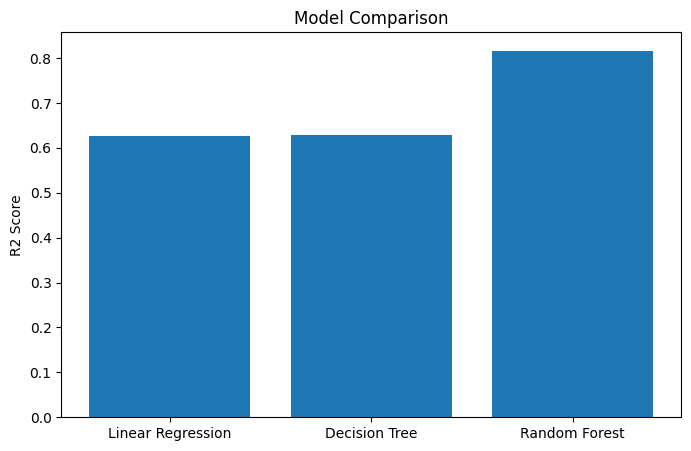

In [22]:
plt.figure(figsize=(8,5))

plt.bar(results['Model'], results['R2 Score'])

plt.title('Model Comparison')

plt.ylabel('R2 Score')

plt.show()

In [23]:
print("""
Conclusion:

Different machine learning models were trained and compared
for house price prediction. After preprocessing and feature
scaling, Random Forest Regressor achieved the best performance
with the highest R2 Score. Therefore, it was selected as the
final model.
""")


Conclusion:

Different machine learning models were trained and compared
for house price prediction. After preprocessing and feature
scaling, Random Forest Regressor achieved the best performance
with the highest R2 Score. Therefore, it was selected as the
final model.



In [24]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV


In [25]:
print("Decision Tree Train Score:",
      dt.score(X_train_scaled, y_train))

print("Decision Tree Test Score:",
      dt.score(X_test_scaled, y_test))

Decision Tree Train Score: 1.0
Decision Tree Test Score: 0.6294725691776935


In [26]:
print("""
Observation:

Decision Tree shows overfitting because the training score
is much higher than the testing score.

Train Score = 1.0
Test Score = 0.629

This indicates the model has memorized the training data
and does not generalize well on unseen data.
""")


Observation:

Decision Tree shows overfitting because the training score
is much higher than the testing score.

Train Score = 1.0
Test Score = 0.629

This indicates the model has memorized the training data
and does not generalize well on unseen data.



In [27]:
print("Random Forest Train Score:",
      rf.score(X_train_scaled, y_train))

print("Random Forest Test Score:",
      rf.score(X_test_scaled, y_test))

Random Forest Train Score: 0.9754359111480769
Random Forest Test Score: 0.8167090228826115


In [28]:
print("""
Observation:

Random Forest performs better than Decision Tree.

Train Score = 0.975
Test Score = 0.817

The gap between training and testing scores is smaller,
indicating less overfitting and better generalization.
""")


Observation:

Random Forest performs better than Decision Tree.

Train Score = 0.975
Test Score = 0.817

The gap between training and testing scores is smaller,
indicating less overfitting and better generalization.



In [30]:
cv_scores = cross_val_score(
    rf,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores:")
print(cv_scores)

print("Average CV Score:")
print(cv_scores.mean())

Cross Validation Scores:
[0.82235727 0.814789   0.81990546 0.81951181 0.81327089]
Average CV Score:
0.817966885339732


In [31]:
print("""
Cross Validation Observation:

The average cross-validation score is 0.818,
which is very close to the test score of 0.817.

This indicates that the Random Forest model is
stable, reliable, and generalizes well to unseen data.

The model is not significantly overfitting and can
be considered a robust choice for house price prediction.
""")


Cross Validation Observation:

The average cross-validation score is 0.818,
which is very close to the test score of 0.817.

This indicates that the Random Forest model is
stable, reliable, and generalizes well to unseen data.

The model is not significantly overfitting and can
be considered a robust choice for house price prediction.



In [33]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None]
}

In [34]:
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

In [35]:
grid_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : th

In [36]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'n_estimators': 100}

Best Cross Validation Score:
0.8124555112399726


In [37]:
best_rf = grid_search.best_estimator_

best_pred = best_rf.predict(X_test_scaled)

print("Tuned Model R2 Score:")
print(r2_score(y_test, best_pred))

Tuned Model R2 Score:
0.8167090228826115


In [38]:
print("""
Hyperparameter Tuning Observation:

GridSearchCV was used to identify the best parameters
for the Random Forest model.

Best Parameters:
max_depth = None
n_estimators = 100

Best Cross Validation Score = 0.812
Tuned Model R2 Score = 0.817

The tuned model achieved strong performance and
maintained good generalization capability.

This confirms that Random Forest is the most suitable
model for California House Price Prediction.
""")


Hyperparameter Tuning Observation:

GridSearchCV was used to identify the best parameters
for the Random Forest model.

Best Parameters:
max_depth = None
n_estimators = 100

Best Cross Validation Score = 0.812
Tuned Model R2 Score = 0.817

The tuned model achieved strong performance and
maintained good generalization capability.

This confirms that Random Forest is the most suitable
model for California House Price Prediction.



In [39]:
print("""
Final Conclusion:

In this task, overfitting detection, cross-validation,
and hyperparameter tuning were performed.

Decision Tree showed overfitting because its training
score was significantly higher than its testing score.

Random Forest achieved better generalization, stable
cross-validation performance, and the highest overall
prediction accuracy.

After hyperparameter tuning using GridSearchCV,
Random Forest remained the best-performing model.

Therefore, Random Forest was selected as the final
model for California House Price Prediction due to
its reliability, stability, and strong predictive
performance.
""")


Final Conclusion:

In this task, overfitting detection, cross-validation,
and hyperparameter tuning were performed.

Decision Tree showed overfitting because its training
score was significantly higher than its testing score.

Random Forest achieved better generalization, stable
cross-validation performance, and the highest overall
prediction accuracy.

After hyperparameter tuning using GridSearchCV,
Random Forest remained the best-performing model.

Therefore, Random Forest was selected as the final
model for California House Price Prediction due to
its reliability, stability, and strong predictive
performance.

